# 📊 PowerCo Churn Analysis-EDA

### 🎯 Objective

The primary goal of this notebook is to investigate basic overview of customer profile and pricing ajustment from client and pricing data.


### 👤 Project Metadata
* **Author:** Yuqing Wang
* **Role:** Data Analytics/ Business Intelligence Consultant  
* **Dataset:** BCG X Forage
https://www.theforage.com/virtual-experience/Tcz8gTtprzAS4xSoK/bcg/data-science-ccdz/background-information

---

### Section 1: EDA of client data

> **Phase 1: Initial Data Auditing in Excel (Detailed steps omitted)**
> *  each row represents one client. total 14,606 rows, no duplication
> *  the electricity and gas consumption of the past 12 months are extremely right skewed
> *  there are new contracts start at every year since 2003, however 95% contract start after 2009, while contracts only ends at 2016 and 2017
>
> note: see detailed column description in pdf file



> **Phase 2: Client profile invesigation**

In [8]:
client_path = os.path.join("data", "client_data.csv")
df_client = pd.read_csv(client_path)
print(df_client.head(3))

                                 id                     channel_sales  \
0  24011ae4ebbe3035111d65fa7c15bc57  foosdfpfkusacimwkcsosbicdxkicaua   
1  d29c2c54acc38ff3c0614d0a653813dd                           MISSING   
2  764c75f661154dac3a6c254cd082ea7d  foosdfpfkusacimwkcsosbicdxkicaua   

   cons_12m  cons_gas_12m  cons_last_month  date_activ    date_end  \
0         0         54946                0  2013-06-15  2016-06-15   
1      4660             0                0  2009-08-21  2016-08-30   
2       544             0                0  2010-04-16  2016-04-16   

  date_modif_prod date_renewal  forecast_cons_12m  ...  has_gas  imp_cons  \
0      2015-11-01   2015-06-23               0.00  ...        t       0.0   
1      2009-08-21   2015-08-31             189.95  ...        f       0.0   
2      2010-04-16   2015-04-17              47.96  ...        f       0.0   

   margin_gross_pow_ele  margin_net_pow_ele  nb_prod_act  net_margin  \
0                 25.44               25.44  

In [9]:
print(df_client.info())
print(df_client.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

Insights:
We can tell that the comsumptions and power max of clients are extremely right skewed, which means different clients "weights" differently


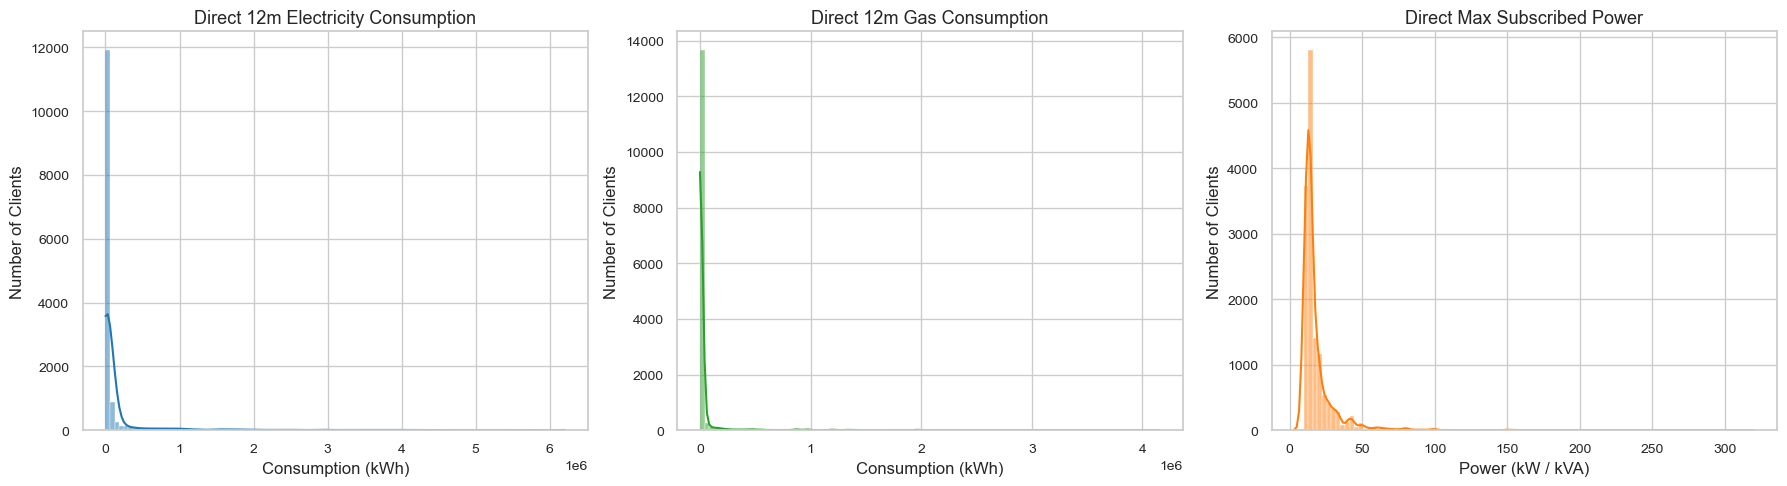

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 100         
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df_client, x='cons_12m', bins=100, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Direct 12m Electricity Consumption')
axes[0].set_xlabel('Consumption (kWh)')
axes[0].set_ylabel('Number of Clients')

sns.histplot(data=df_client, x='cons_gas_12m', bins=100, kde=True, ax=axes[1], color='#2ca02c')
axes[1].set_title('Direct 12m Gas Consumption')
axes[1].set_xlabel('Consumption (kWh)')
axes[1].set_ylabel('Number of Clients')
sns.histplot(data=df_client, x='pow_max', bins=100, kde=True, ax=axes[2], color='#ff7f0e')
axes[2].set_title('Direct Max Subscribed Power')
axes[2].set_xlabel('Power (kW / kVA)')
axes[2].set_ylabel('Number of Clients')
plt.tight_layout()
plt.savefig('raw_numerical_distributions.png', bbox_inches='tight')
plt.show()

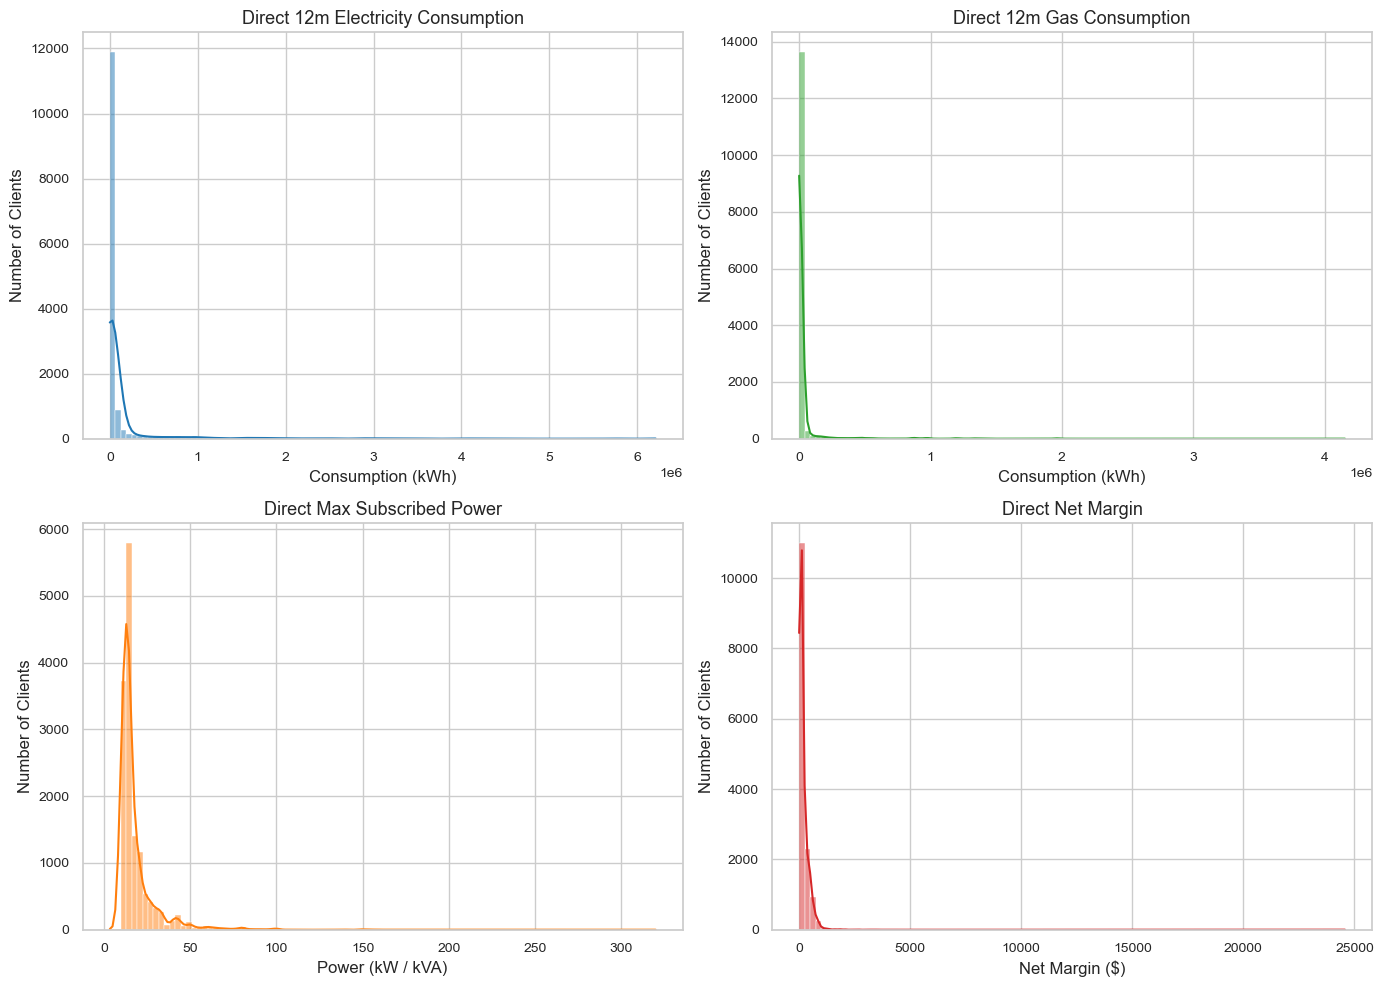

In [16]:


# 1. Enforce crisp, professional layout styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 100         
})

# 2. Reshape canvas: Change to 2 rows, 2 columns and use a squarer aspect ratio (14x10)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Row 0: Electricity and Gas ---
# Top-Left [0, 0]: Direct Electricity Consumption
sns.histplot(data=df_client, x='cons_12m', bins=100, kde=True, ax=axes[0, 0], color='#1f77b4')
axes[0, 0].set_title('Direct 12m Electricity Consumption')
axes[0, 0].set_xlabel('Consumption (kWh)')
axes[0, 0].set_ylabel('Number of Clients')

# Top-Right [0, 1]: Direct Gas Consumption
sns.histplot(data=df_client, x='cons_gas_12m', bins=100, kde=True, ax=axes[0, 1], color='#2ca02c')
axes[0, 1].set_title('Direct 12m Gas Consumption')
axes[0, 1].set_xlabel('Consumption (kWh)')
axes[0, 1].set_ylabel('Number of Clients')

# --- Row 1: Subscribed Power and Net Margin ---
# Bottom-Left [1, 0]: Direct Max Subscribed Power
sns.histplot(data=df_client, x='pow_max', bins=100, kde=True, ax=axes[1, 0], color='#ff7f0e')
axes[1, 0].set_title('Direct Max Subscribed Power')
axes[1, 0].set_xlabel('Power (kW / kVA)')
axes[1, 0].set_ylabel('Number of Clients')

# Bottom-Right [1, 1]: Direct Net Margin
sns.histplot(data=df_client, x='net_margin', bins=100, kde=True, ax=axes[1, 1], color='#d62728')
axes[1, 1].set_title('Direct Net Margin')
axes[1, 1].set_xlabel('Net Margin ($)')
axes[1, 1].set_ylabel('Number of Clients')

# 3. Clean up grid padding and save the updated 2x2 image asset for GitHub
plt.tight_layout()
plt.savefig('raw_numerical_distributions_2x2.png', bbox_inches='tight')
plt.show()

In this graph, we can tell that custumer's comsumptions, power max, and net margin is heavily right skewed. Most custumers fell into a range of 0-1000,000 kWh for electricity and gas consumptions, 0-100 kW/kVA power max, and 0-2500 for net margin.  There exists few numbers of outliers that has bigger numbers than average by far in each graphs.

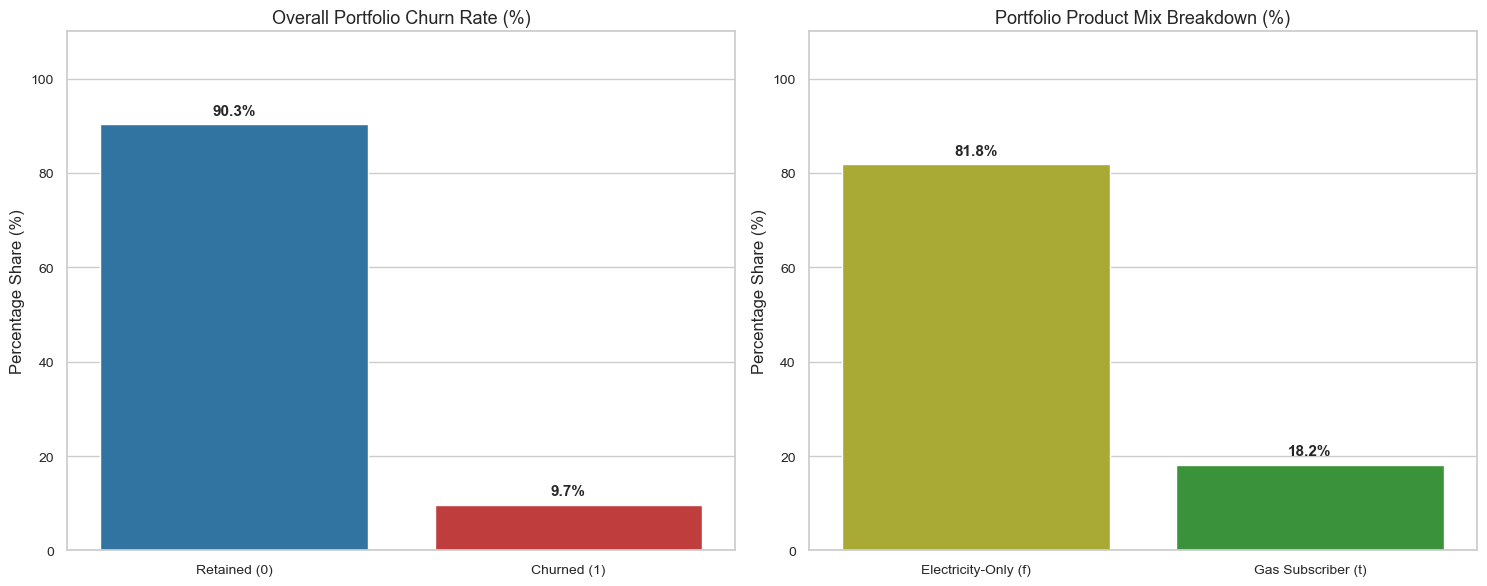

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

churn_pct = df_client['churn'].value_counts(normalize=True) * 100
retained_val = churn_pct.get(0, 0)
churned_val = churn_pct.get(1, 0)

x_churn = ['Retained (0)', 'Churned (1)']
y_churn = [retained_val, churned_val]
colors_churn = ['#1f77b4', '#d62728']  # Blue for retention, Red for alert churn

sns.barplot(x=x_churn, y=y_churn, ax=axes[0], palette=colors_churn, hue=x_churn, legend=False)
axes[0].set_title('Overall Portfolio Churn Rate (%)')
axes[0].set_ylabel('Percentage Share (%)')
axes[0].set_ylim(0, 110)


for i, val in enumerate(y_churn):
    axes[0].text(i, val + 2, f"{val:.1f}%", ha='center', fontweight='bold', size=11)


gas_pct = df_client['has_gas'].value_counts(normalize=True) * 100
no_gas_val = gas_pct.get('f', 0)
has_gas_val = gas_pct.get('t', 0)

x_gas = ['Electricity-Only (f)', 'Gas Subscriber (t)']
y_gas = [no_gas_val, has_gas_val]
colors_gas = ['#bcbd22', '#2ca02c']  # Earthy gold for single-product, green for gas line

sns.barplot(x=x_gas, y=y_gas, ax=axes[1], palette=colors_gas, hue=x_gas, legend=False)
axes[1].set_title('Portfolio Product Mix Breakdown (%)')
axes[1].set_ylabel('Percentage Share (%)')
axes[1].set_ylim(0, 110)

for i, val in enumerate(y_gas):
    axes[1].text(i, val + 2, f"{val:.1f}%", ha='center', fontweight='bold', size=11)

plt.tight_layout()
plt.savefig('portfolio_baseline_percentages.png', bbox_inches='tight')
plt.show()

Insight: all clients subcribed eletricity service, and 18.2% of them also subscribed gas service in addition. Up to today, the company has a churn rate of 9.7%

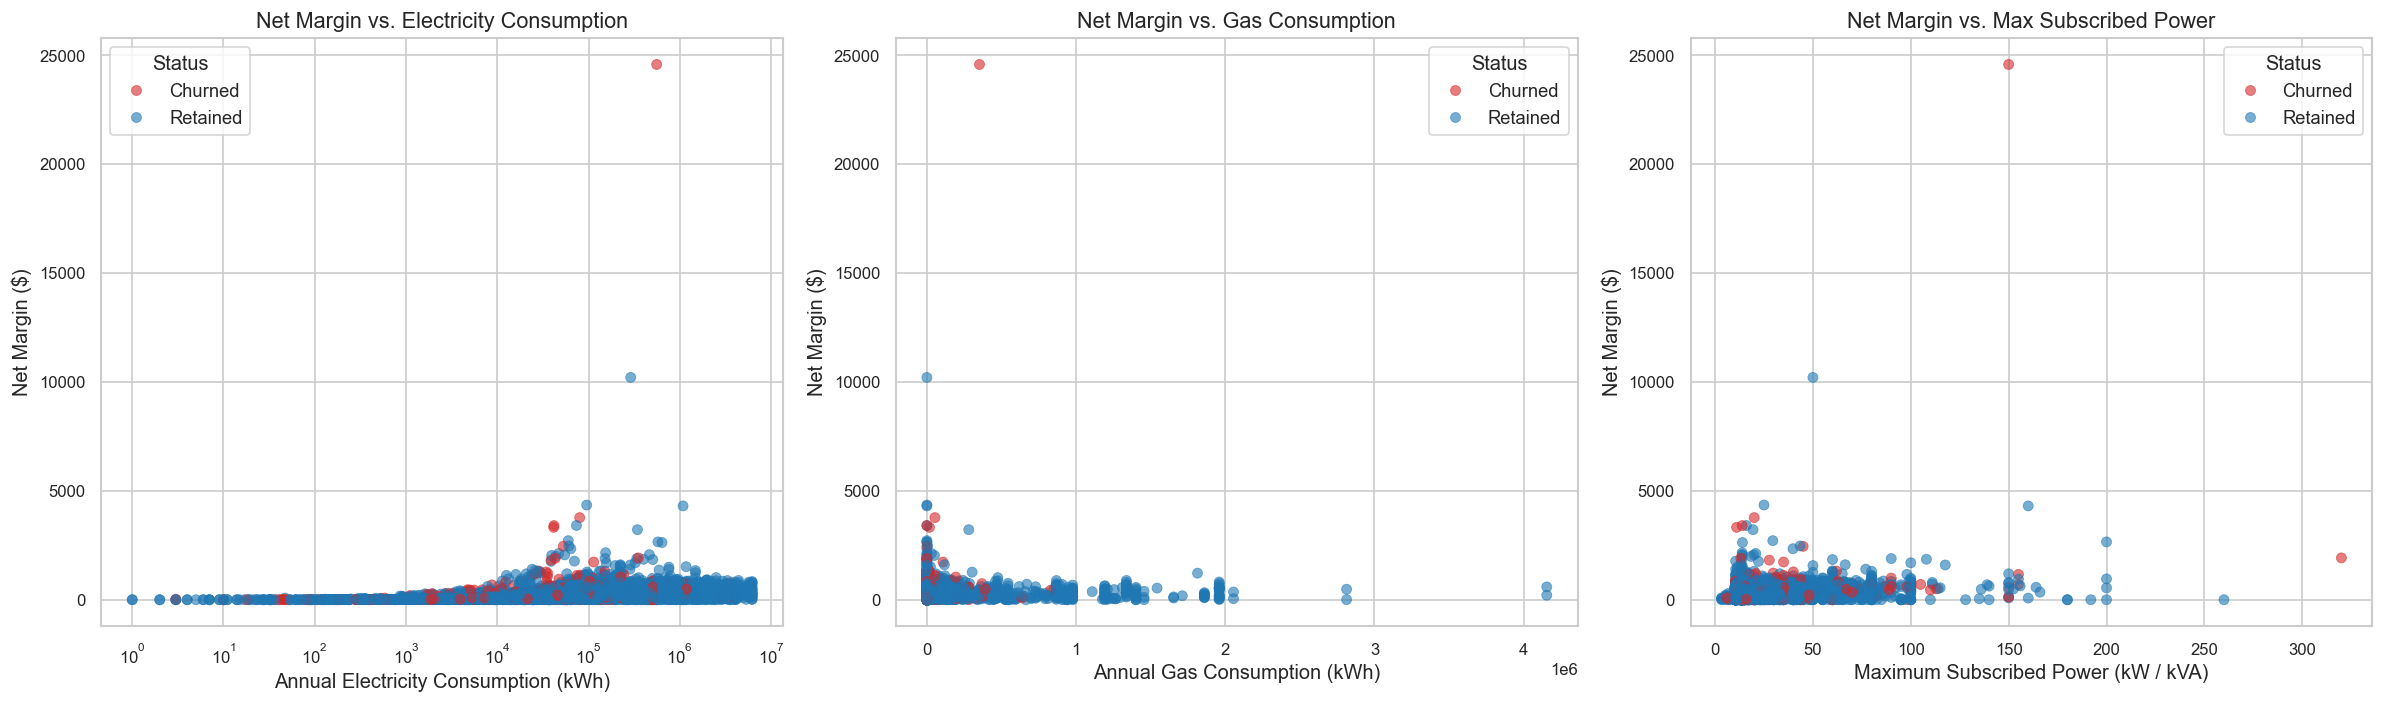

In [19]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 120          # Ensures scatter points remain crisp
})

# 2. Ingest your data frame using your root directory setup
client_path = os.path.join("data", "client_data.csv")
df_client = pd.read_csv(client_path)

# 3. Establish clean categorical mappings for your legend
df_client['Status'] = df_client['churn'].map({0: 'Retained', 1: 'Churned'})
color_palette = {'Retained': '#1f77b4', 'Churned': '#d62728'}  # Blue vs. Red

# 4. Initialize a 1-row, 3-column plot layout
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Scatter Plot 1: Net Margin vs. Electricity Consumption ---
sns.scatterplot(
    data=df_client,
    x='cons_12m',
    y='net_margin',
    hue='Status',
    palette=color_palette,
    alpha=0.6,
    edgecolor=None,
    ax=axes[0]
)
axes[0].set_title('Net Margin vs. Electricity Consumption')
axes[0].set_xlabel('Annual Electricity Consumption (kWh)')
axes[0].set_ylabel('Net Margin ($)')
axes[0].set_xscale('log')  # Log scale used to handle extreme skewness

# --- Scatter Plot 2: Net Margin vs. Gas Consumption ---
sns.scatterplot(
    data=df_client,
    x='cons_gas_12m',
    y='net_margin',
    hue='Status',
    palette=color_palette,
    alpha=0.6,
    edgecolor=None,
    ax=axes[1]
)
axes[1].set_title('Net Margin vs. Gas Consumption')
axes[1].set_xlabel('Annual Gas Consumption (kWh)')
axes[1].set_ylabel('Net Margin ($)')


# --- Scatter Plot 3: Net Margin vs. Max Power Capacity ---
sns.scatterplot(
    data=df_client,
    x='pow_max',
    y='net_margin',
    hue='Status',
    palette=color_palette,
    alpha=0.6,
    edgecolor=None,
    ax=axes[2]
)
axes[2].set_title('Net Margin vs. Max Subscribed Power')
axes[2].set_xlabel('Maximum Subscribed Power (kW / kVA)')
axes[2].set_ylabel('Net Margin ($)')
# Standard scale works perfectly for pow_max as the values cluster closely

# 5. Optimize alignment and output to workspace assets
plt.tight_layout()
plt.savefig('margin_vs_features_scatter.png', bbox_inches='tight')
plt.show()

To better visualze the scatter plot, we need to get rid of 2 extremely outliers.

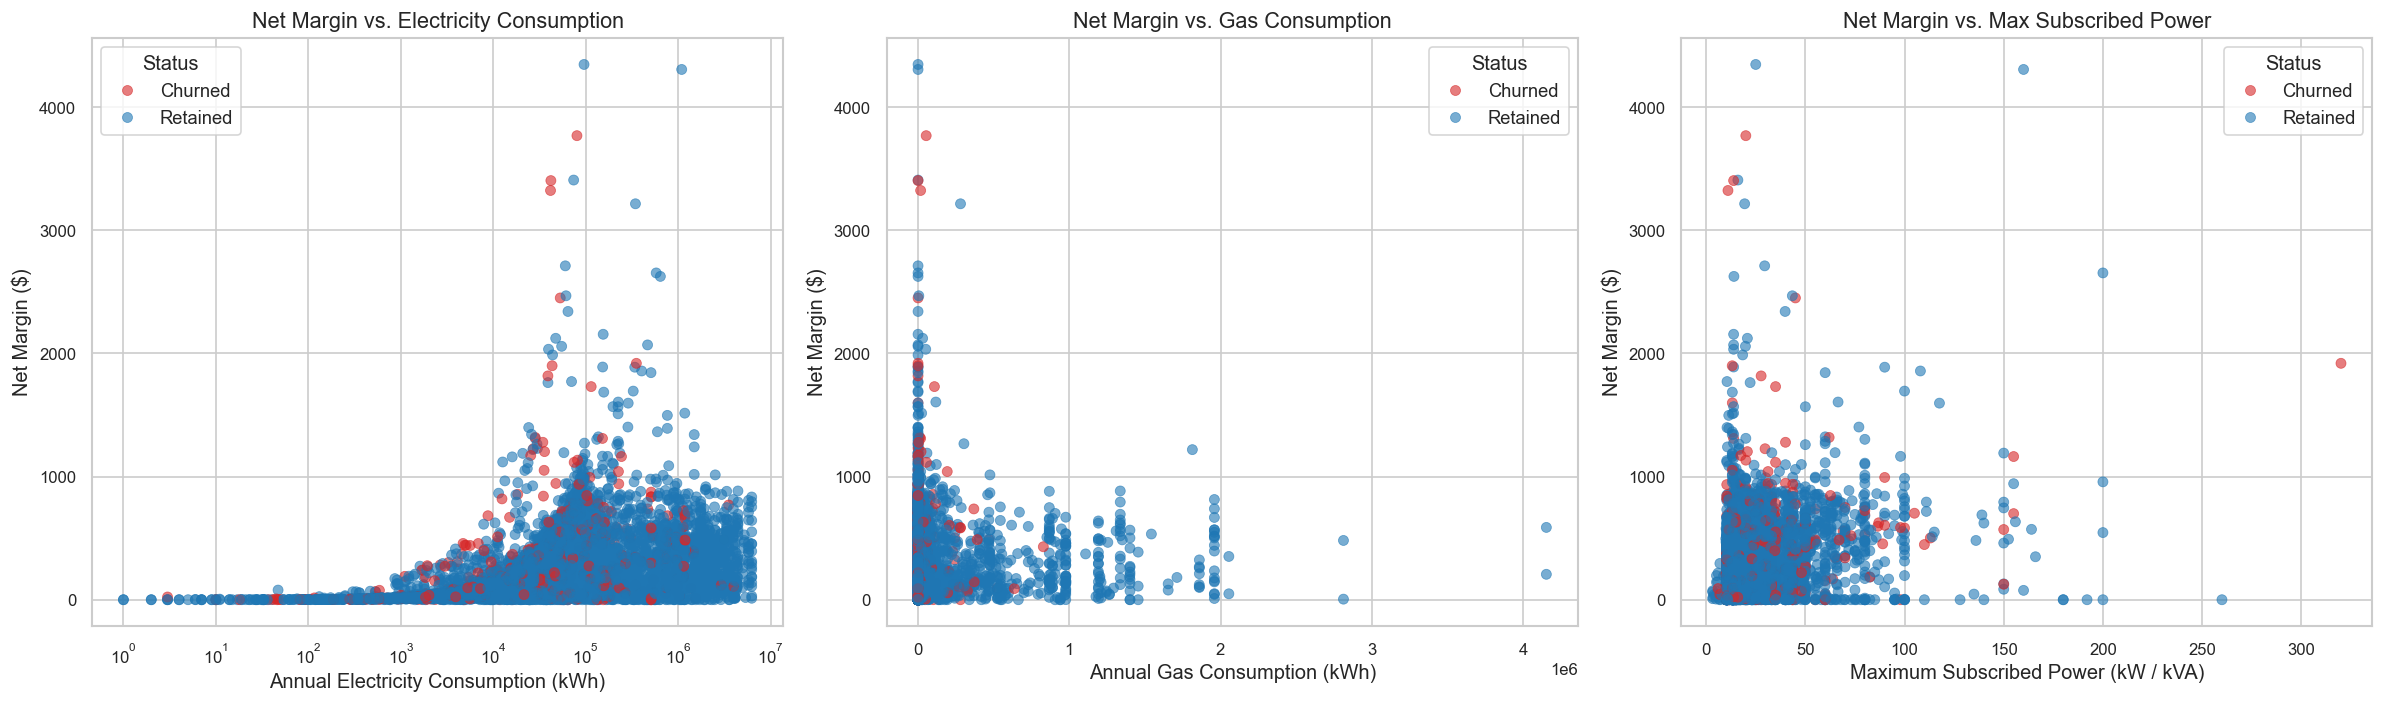

In [18]:


# 1. Enforce high-resolution professional aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 120          
})

# 2. Ingest your dataframe
client_path = os.path.join("data", "client_data.csv")
df_client = pd.read_csv(client_path)

# 3. CRITICAL STEP: Filter out the 2 extreme outliers (> 5000)
# This clean boolean mask isolates our core business cluster
df_filtered = df_client[df_client['net_margin'] <= 5000].copy()

# 4. Establish clean categorical mappings for your legend
df_filtered['Status'] = df_filtered['churn'].map({0: 'Retained', 1: 'Churned'})
color_palette = {'Retained': '#1f77b4', 'Churned': '#d62728'} 

# 5. Initialize the 1-row, 3-column plot layout
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Scatter Plot 1: Net Margin vs. Electricity Consumption (Filtered) ---
sns.scatterplot(
    data=df_filtered,
    x='cons_12m',
    y='net_margin',
    hue='Status',
    palette=color_palette,
    alpha=0.6,
    edgecolor=None,
    ax=axes[0]
)
axes[0].set_title('Net Margin vs. Electricity Consumption')
axes[0].set_xlabel('Annual Electricity Consumption (kWh)')
axes[0].set_ylabel('Net Margin ($)')
axes[0].set_xscale('log')  

# --- Scatter Plot 2: Net Margin vs. Gas Consumption (Filtered) ---
sns.scatterplot(
    data=df_filtered,
    x='cons_gas_12m',
    y='net_margin',
    hue='Status',
    palette=color_palette,
    alpha=0.6,
    edgecolor=None,
    ax=axes[1]
)
axes[1].set_title('Net Margin vs. Gas Consumption')
axes[1].set_xlabel('Annual Gas Consumption (kWh)')
axes[1].set_ylabel('Net Margin ($)')
 

# --- Scatter Plot 3: Net Margin vs. Max Power Capacity (Filtered) ---
sns.scatterplot(
    data=df_filtered,
    x='pow_max',
    y='net_margin',
    hue='Status',
    palette=color_palette,
    alpha=0.6,
    edgecolor=None,
    ax=axes[2]
)
axes[2].set_title('Net Margin vs. Max Subscribed Power')
axes[2].set_xlabel('Maximum Subscribed Power (kW / kVA)')
axes[2].set_ylabel('Net Margin ($)')

# 6. Optimize alignment and output to workspace assets
plt.tight_layout()
plt.savefig('margin_vs_features_filtered_scatter.png', bbox_inches='tight')
plt.show()

Insights
* churned clients are mostly those having high annual electricity consumption with different levels of net margin.
* All clients with gas consumption>1000,000 retained
* it's very hard to say churn has anything to do with Max power simply from the scatter plot

---

### Section 2: EDA of price data

> **Phase 1: Initial Data Auditing in Excel (Detailed steps omitted)**
> *  Price adjustment happens once a month, and the data only has the pricing information of  the year 2015.
> *  Price data only has information of electricity service, no gas.
> *  Prices are divided into 2 parts: fixed rental price for infrastructure each month and unit prices for power.
> *  prices vary depending on the time sections. there are peak, mid peak and off peak.
>   
> note: see detailed column description in pdf file

> **Phase 2: Price trend invesigation**

In [20]:
client_path = os.path.join("data", "price_data.csv")
df_price = pd.read_csv(client_path)
print(df_price.head(3))

                                 id  price_date  price_off_peak_var  \
0  038af19179925da21a25619c5a24b745  2015-01-01            0.151367   
1  038af19179925da21a25619c5a24b745  2015-02-01            0.151367   
2  038af19179925da21a25619c5a24b745  2015-03-01            0.151367   

   price_peak_var  price_mid_peak_var  price_off_peak_fix  price_peak_fix  \
0             0.0                 0.0           44.266931             0.0   
1             0.0                 0.0           44.266931             0.0   
2             0.0                 0.0           44.266931             0.0   

   price_mid_peak_fix  
0                 0.0  
1                 0.0  
2                 0.0  


In [23]:
df_price.info()
df_price.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


insight:
* The minimum value of prices are zero, which means there are at least one client didn't subcribe the according service. Therefore,we should exclude the 0 values when calculating the average prices.
*  range of the prices are small. for example, the max of `price_off_peak_var` is 0.280700 $ and the first quartile is 0.125976. However, the max value is more than double of the price! Therefore, we need to normalize the prices to better interpret the price trend.

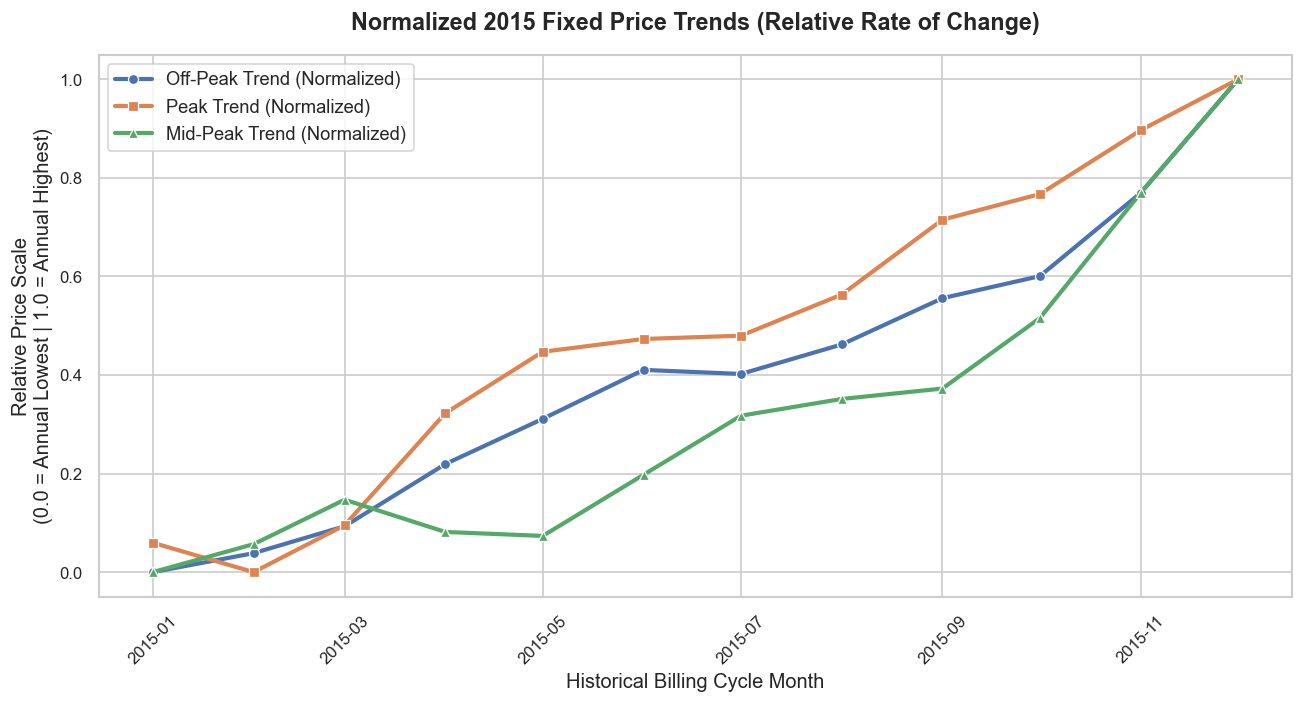

In [33]:
# 1. Calculate the raw monthly averages (excluding zeros)
fix_cols = ['price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']
df_fix_only = df_price[['id', 'price_date'] + fix_cols].copy()

for col in fix_cols:
    df_fix_only[col] = df_fix_only[col].replace(0, float('nan'))

monthly_averages = df_fix_only.groupby('price_date')[fix_cols].mean().reset_index()
monthly_averages = monthly_averages.sort_values('price_date')

# 2. Apply Min-Max Normalization to force all columns into a 0.0 to 1.0 range
# Formula: (Value - Min) / (Max - Min)
monthly_normalized = monthly_averages.copy()
for col in fix_cols:
    col_min = monthly_averages[col].min()
    col_max = monthly_averages[col].max()
    
    # Standard check to prevent dividing by zero if a price never changed
    if col_max != col_min:
        monthly_normalized[col] = (monthly_averages[col] - col_min) / (col_max - col_min)
    else:
        monthly_normalized[col] = 0.0

# 3. Plot the Normalized Trend Lines
fig, ax = plt.subplots(figsize=(11, 6))

sns.lineplot(data=monthly_normalized, x='price_date', y='price_off_peak_fix', marker='o', linewidth=2.5, label='Off-Peak Trend (Normalized)')
sns.lineplot(data=monthly_normalized, x='price_date', y='price_peak_fix', marker='s', linewidth=2.5, label='Peak Trend (Normalized)')
sns.lineplot(data=monthly_normalized, x='price_date', y='price_mid_peak_fix', marker='^', linewidth=2.5, label='Mid-Peak Trend (Normalized)')

# 4. Final Polish and Presentation Labels
ax.set_title('Normalized 2015 Fixed Price Trends (Relative Rate of Change)', pad=15, weight='bold')
ax.set_xlabel('Historical Billing Cycle Month')
ax.set_ylabel('Relative Price Scale\n(0.0 = Annual Lowest | 1.0 = Annual Highest)')
plt.xticks(rotation=45)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

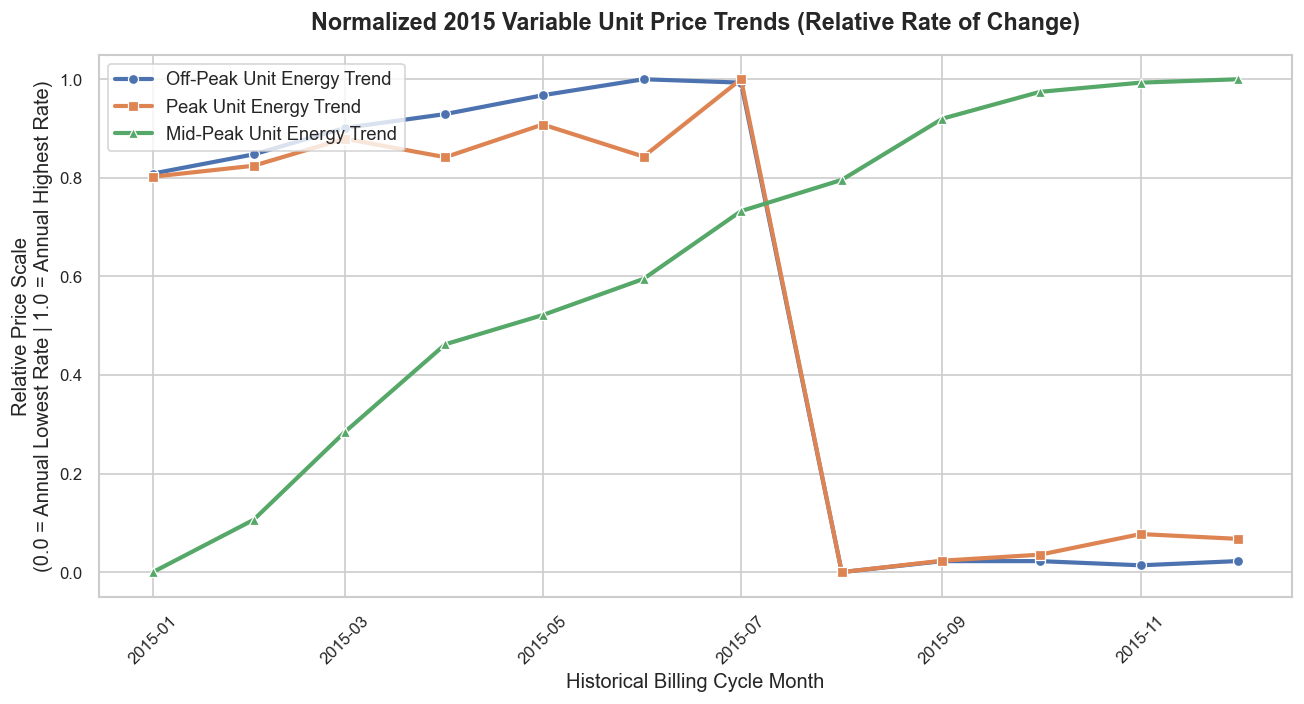

In [34]:
# 1. Isolate and copy the 3 variable unit price columns
var_cols = ['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var']
df_var_only = df_price[['id', 'price_date'] + var_cols].copy()

# 2. Exclude 0 values (if any) by replacing them with NaN 
# Note: For variable energy, 0s usually mean the account didn't use power in that window, 
# but we filter them out to ensure they don't skew the true baseline tariff average.
for col in var_cols:
    df_var_only[col] = df_var_only[col].replace(0, float('nan'))

# 3. Calculate the exact portfolio average per month
monthly_var_averages = df_var_only.groupby('price_date')[var_cols].mean().reset_index()
monthly_var_averages = monthly_var_averages.sort_values('price_date')

# 4. Apply Min-Max Normalization to force the unit scales into a 0.0 to 1.0 box
# Formula: (Current_Month_Average - Annual_Minimum) / (Annual_Maximum - Annual_Minimum)
monthly_var_normalized = monthly_var_averages.copy()
for col in var_cols:
    col_min = monthly_var_averages[col].min()
    col_max = monthly_var_averages[col].max()
    
    if col_max != col_min:
        monthly_var_normalized[col] = (monthly_var_averages[col] - col_min) / (col_max - col_min)
    else:
        monthly_var_normalized[col] = 0.0

# 5. Render the Normalized Unit Price Trends
fig, ax = plt.subplots(figsize=(11, 6))

sns.lineplot(data=monthly_var_normalized, x='price_date', y='price_off_peak_var', marker='o', linewidth=2.5, label='Off-Peak Unit Energy Trend')
sns.lineplot(data=monthly_var_normalized, x='price_date', y='price_peak_var', marker='s', linewidth=2.5, label='Peak Unit Energy Trend')
sns.lineplot(data=monthly_var_normalized, x='price_date', y='price_mid_peak_var', marker='^', linewidth=2.5, label='Mid-Peak Unit Energy Trend')

# 6. Presentation Labels and Adjustments
ax.set_title('Normalized 2015 Variable Unit Price Trends (Relative Rate of Change)', pad=15, weight='bold')
ax.set_xlabel('Historical Billing Cycle Month')
ax.set_ylabel('Relative Price Scale\n(0.0 = Annual Lowest Rate | 1.0 = Annual Highest Rate)')
plt.xticks(rotation=45)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

Insight：
* The fixed prices of all time sections show increasing trend throughout the year
* The unit price of mid-peak shows a stready increasing trend throughout the year. Price for off peak and peak however, increase very slowly Jan-Jul, and dropped significantly Jul-Aug and stayed low Aug-Dec.

### Conclusion
This notebook investigated the basic features of client and price dataset. More analysis see the second notebook